# Imports

In [ ]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tifffile as tiff

# Dataset Path

In [2]:
DATASET_PATH = r"C:\Users\kritr\Downloads\INTERNSHIP\GalaxEye_Segmentation_Assignment\dataset"

train_path = os.path.join(DATASET_PATH, "train")

pre_path = os.path.join(train_path, "pre-event")
post_path = os.path.join(train_path, "post-event")
target_path = os.path.join(train_path, "target")

print("Pre-event Path:", pre_path)
print("Post-event Path:", post_path)
print("Target Path:", target_path)

Pre-event Path: C:\Users\kritr\Downloads\INTERNSHIP\GalaxEye_Segmentation_Assignment\dataset\train\pre-event
Post-event Path: C:\Users\kritr\Downloads\INTERNSHIP\GalaxEye_Segmentation_Assignment\dataset\train\post-event
Target Path: C:\Users\kritr\Downloads\INTERNSHIP\GalaxEye_Segmentation_Assignment\dataset\train\target


## Count Files

In [3]:
pre_files = sorted(os.listdir(pre_path))
post_files = sorted(os.listdir(post_path))
target_files = sorted(os.listdir(target_path))

print("Number of pre-event images :", len(pre_files))
print("Number of post-event images:", len(post_files))
print("Number of target masks     :", len(target_files))

Number of pre-event images : 2781
Number of post-event images: 2781
Number of target masks     : 2781


## Checking File-Name

In [4]:
for i in range(5):
    print("PRE   :", pre_files[-i])
    print("POST  :", post_files[-i])
    print("TARGET:", target_files[-i])
    print("-" * 44)

PRE   : scene_01_000001_building_damage.tif
POST  : scene_01_000001_building_damage.tif
TARGET: scene_01_000001_building_damage.tif
--------------------------------------------
PRE   : scene_08_001001_building_damage.tif
POST  : scene_08_001001_building_damage.tif
TARGET: scene_08_001001_building_damage.tif
--------------------------------------------
PRE   : scene_08_001000_building_damage.tif
POST  : scene_08_001000_building_damage.tif
TARGET: scene_08_001000_building_damage.tif
--------------------------------------------
PRE   : scene_08_000999_building_damage.tif
POST  : scene_08_000999_building_damage.tif
TARGET: scene_08_000999_building_damage.tif
--------------------------------------------
PRE   : scene_08_000998_building_damage.tif
POST  : scene_08_000998_building_damage.tif
TARGET: scene_08_000998_building_damage.tif
--------------------------------------------


## Loading One Sample image

In [5]:
sample_name = pre_files[0]

pre_image_path = os.path.join(pre_path, sample_name)
post_image_path = os.path.join(post_path, sample_name)
target_mask_path = os.path.join(target_path, sample_name)

pre_image = tiff.imread(pre_image_path)
post_image = tiff.imread(post_image_path)
target_mask = tiff.imread(target_mask_path)

print("Sample Loaded:", sample_name)

Sample Loaded: scene_01_000001_building_damage.tif


## Inspecting Shape and Type of the Images

In [6]:
print("PRE IMAGE")
print("Shape :", pre_image.shape)
print("Dtype :", pre_image.dtype)
print("Min   :", pre_image.min())
print("Max   :", pre_image.max())

print("\nPOST IMAGE")
print("Shape :", post_image.shape)
print("Dtype :", post_image.dtype)
print("Min   :", post_image.min())
print("Max   :", post_image.max())

print("\nTARGET MASK")
print("Shape :", target_mask.shape)
print("Dtype :", target_mask.dtype)
print("Unique Values :", np.unique(target_mask))

PRE IMAGE
Shape : (1024, 1024, 3)
Dtype : uint8
Min   : 0
Max   : 218

POST IMAGE
Shape : (1024, 1024)
Dtype : uint8
Min   : 0
Max   : 238

TARGET MASK
Shape : (1024, 1024)
Dtype : uint8
Unique Values : [0 1]


## Visualising Image

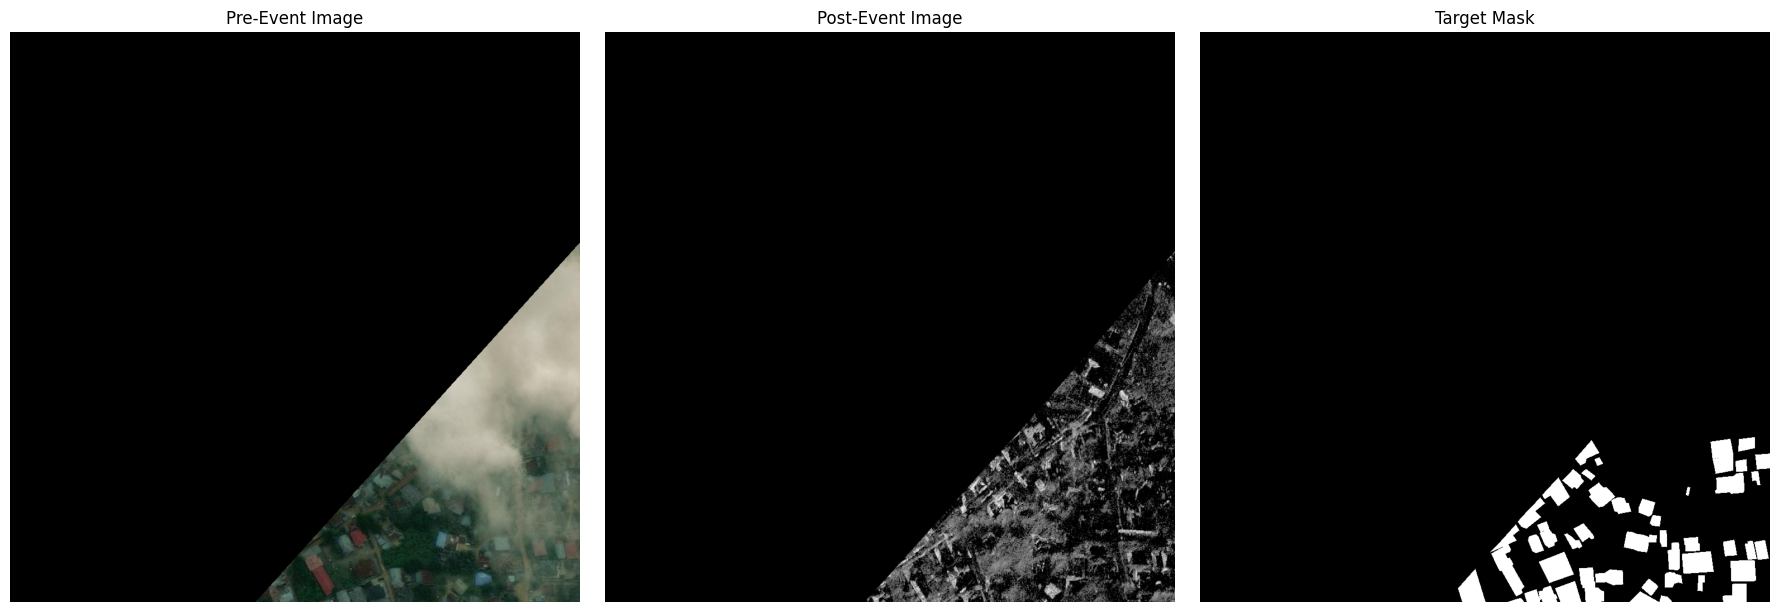

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# PRE-EVENT
if len(pre_image.shape) == 3:
    axes[0].imshow(pre_image[:, :, :3])
else:
    axes[0].imshow(pre_image, cmap="gray")

axes[0].set_title("Pre-Event Image")
axes[0].axis("off")

# POST-EVENT
if len(post_image.shape) == 3:
    axes[1].imshow(post_image[:, :, :3])
else:
    axes[1].imshow(post_image, cmap="gray")

axes[1].set_title("Post-Event Image")
axes[1].axis("off")

# TARGET MASK
axes[2].imshow(target_mask, cmap="gray")
axes[2].set_title("Target Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

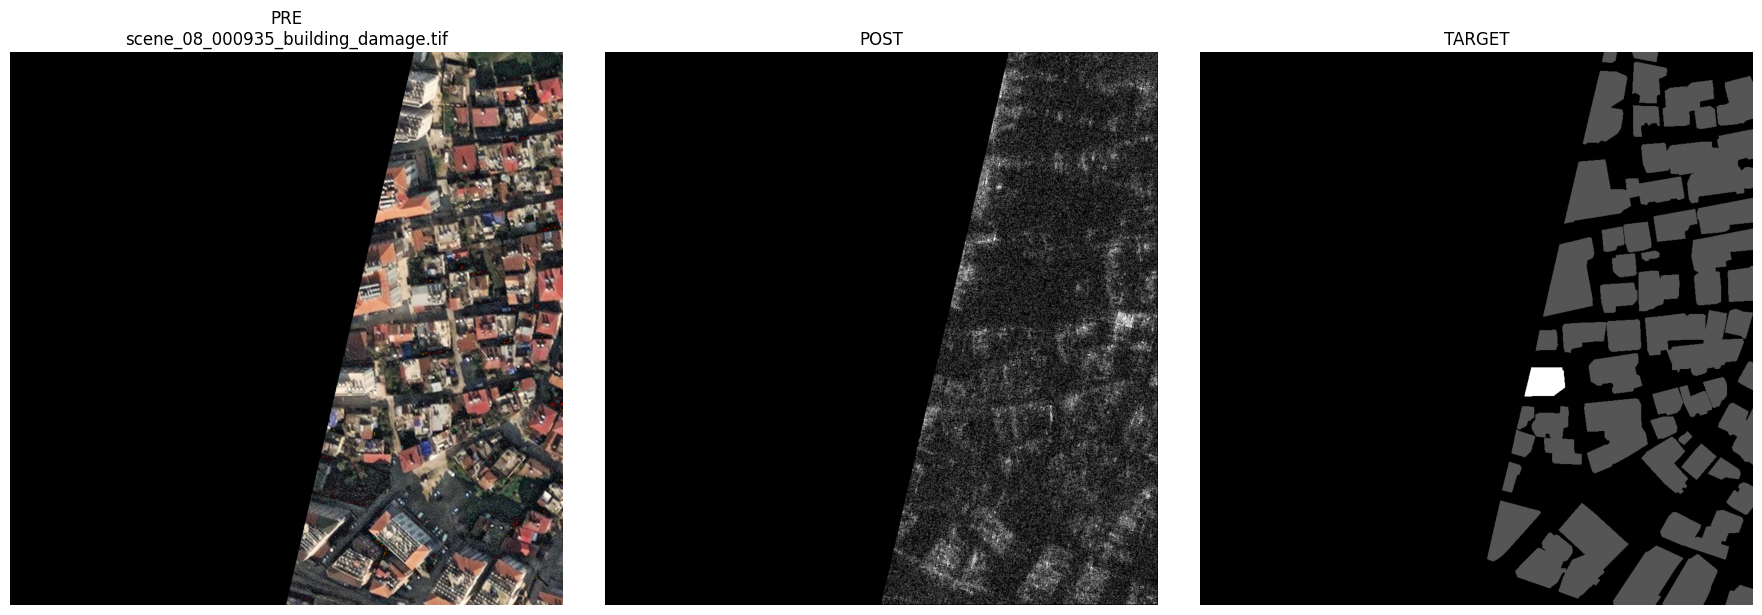

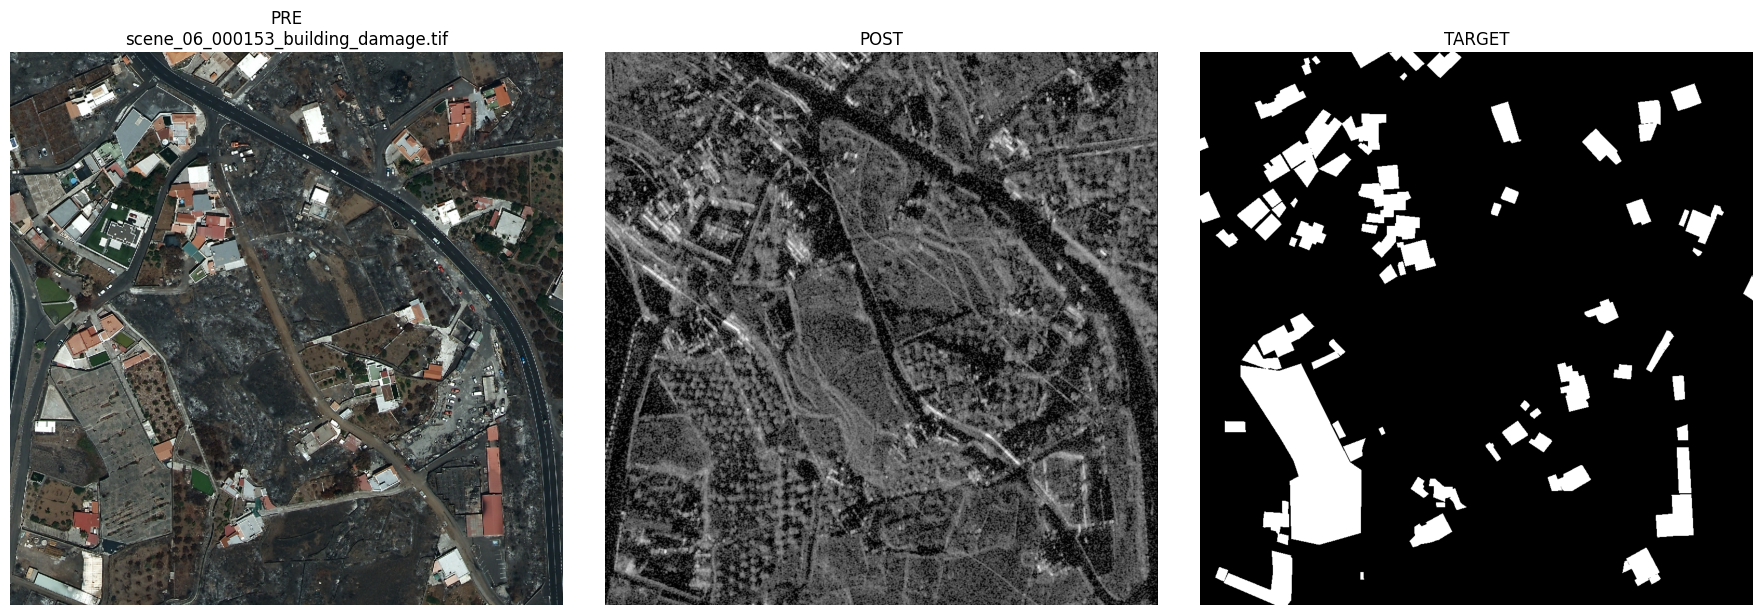

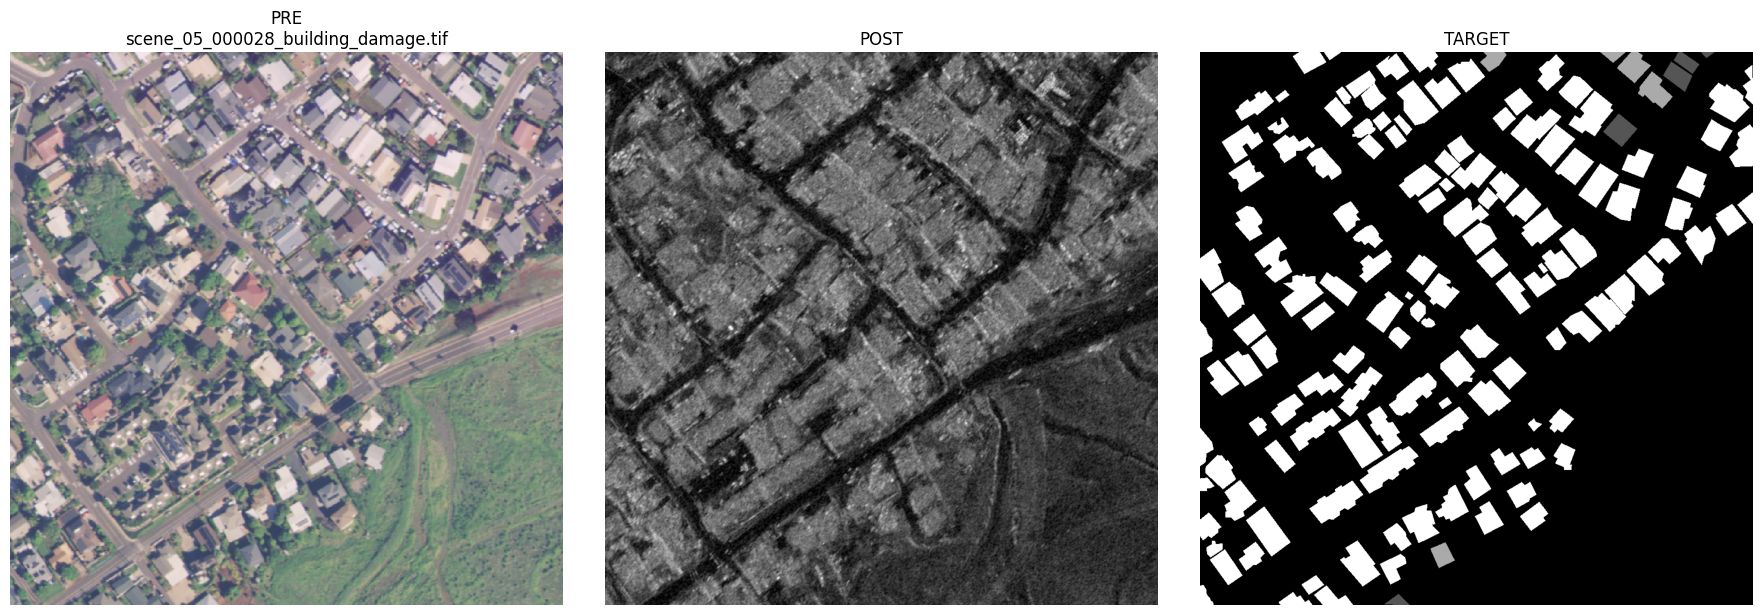

In [8]:
random_indices = np.random.choice(len(pre_files), 3, replace=False)

for idx in random_indices:

    sample_name = pre_files[idx]

    pre_image = tiff.imread(os.path.join(pre_path, sample_name))
    post_image = tiff.imread(os.path.join(post_path, sample_name))
    target_mask = tiff.imread(os.path.join(target_path, sample_name))

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # PRE
    if len(pre_image.shape) == 3:
        axes[0].imshow(pre_image[:, :, :3])
    else:
        axes[0].imshow(pre_image, cmap="gray")

    axes[0].set_title(f"PRE\n{sample_name}")
    axes[0].axis("off")

    # POST
    if len(post_image.shape) == 3:
        axes[1].imshow(post_image[:, :, :3])
    else:
        axes[1].imshow(post_image, cmap="gray")

    axes[1].set_title("POST")
    axes[1].axis("off")

    # TARGET
    axes[2].imshow(target_mask, cmap="gray")
    axes[2].set_title("TARGET")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

### Mask Distribution Analysis

In [9]:
all_unique_values = []

for file_name in target_files[:100]:   # first 100 masks for quick analysis

    mask = tiff.imread(os.path.join(target_path, file_name))

    unique_vals = np.unique(mask)

    all_unique_values.extend(unique_vals)

print("Unique values found across masks:")
print(sorted(set(all_unique_values)))

Unique values found across masks:
[np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3)]


### Pixel Distribution

In [10]:
from collections import Counter

pixel_counter = Counter()

for file_name in target_files[:100]:

    mask = tiff.imread(os.path.join(target_path, file_name))

    unique, counts = np.unique(mask, return_counts=True)

    for u, c in zip(unique, counts):
        pixel_counter[int(u)] += int(c)

print(pixel_counter)

Counter({0: 99218580, 1: 5118781, 2: 333994, 3: 186245})


## Label Remapping Test

In [11]:
def remap_mask(mask):

    remapped = np.zeros_like(mask)

    remapped[(mask == 2) | (mask == 3)] = 1

    return remapped


sample_mask = tiff.imread(target_mask_path)

binary_mask = remap_mask(sample_mask)

print("Original Unique Values :", np.unique(sample_mask))
print("Binary Unique Values   :", np.unique(binary_mask))

Original Unique Values : [0 1]
Binary Unique Values   : [0]


### Visualising Remapped Labels

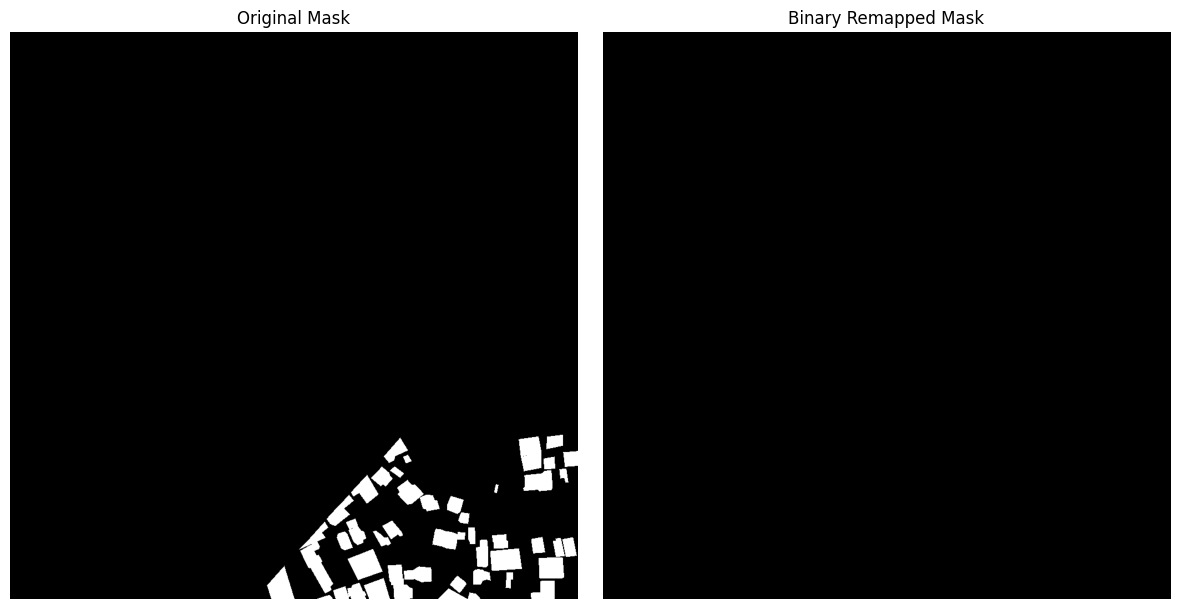

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(sample_mask, cmap="gray")
axes[0].set_title("Original Mask")
axes[0].axis("off")

axes[1].imshow(binary_mask, cmap="gray")
axes[1].set_title("Binary Remapped Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Counting Empty Mask

In [13]:
empty_masks = 0
non_empty_masks = 0

for file_name in target_files:

    mask = tiff.imread(os.path.join(target_path, file_name))

    # Apply remapping
    binary_mask = np.zeros_like(mask)
    binary_mask[(mask == 2) | (mask == 3)] = 1

    if np.sum(binary_mask) == 0:
        empty_masks += 1
    else:
        non_empty_masks += 1

print(f"Empty masks     : {empty_masks}")
print(f"Non-empty masks : {non_empty_masks}")

print(f"\nPercentage Empty     : {(empty_masks/len(target_files))*100:.2f}%")
print(f"Percentage Non-Empty : {(non_empty_masks/len(target_files))*100:.2f}%")

Empty masks     : 2068
Non-empty masks : 713

Percentage Empty     : 74.36%
Percentage Non-Empty : 25.64%


## Damage Coverage Analysis

In [14]:
damage_percentages = []

for file_name in target_files:

    mask = tiff.imread(os.path.join(target_path, file_name))

    binary_mask = np.zeros_like(mask)
    binary_mask[(mask == 2) | (mask == 3)] = 1

    total_pixels = binary_mask.size
    changed_pixels = np.sum(binary_mask)

    damage_percentage = (changed_pixels / total_pixels) * 100

    damage_percentages.append(damage_percentage)

damage_percentages = np.array(damage_percentages)

print("Damage Coverage Statistics")
print("-" * 40)
print(f"Mean Damage %   : {damage_percentages.mean():.4f}")
print(f"Median Damage % : {np.median(damage_percentages):.4f}")
print(f"Max Damage %    : {damage_percentages.max():.4f}")
print(f"Min Damage %    : {damage_percentages.min():.4f}")

Damage Coverage Statistics
----------------------------------------
Mean Damage %   : 1.5695
Median Damage % : 0.0000
Max Damage %    : 68.5387
Min Damage %    : 0.0000


### Visualise Distribution of Damage

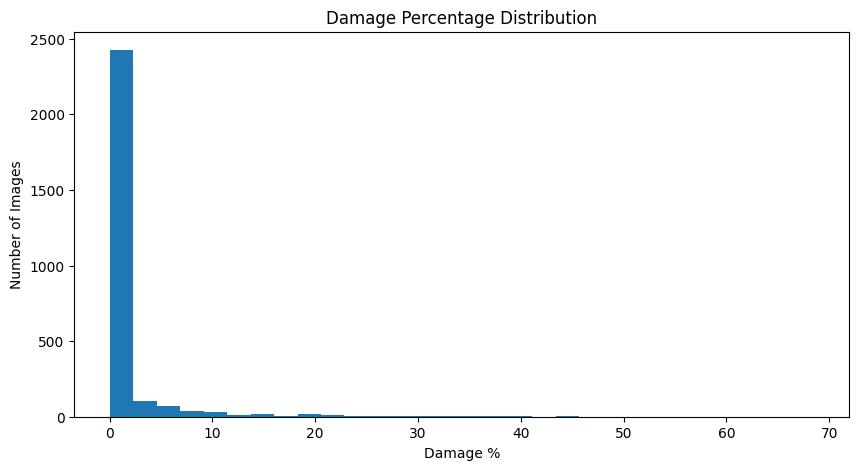

In [15]:
plt.figure(figsize=(10,5))

plt.hist(damage_percentages, bins=30)

plt.title("Damage Percentage Distribution")
plt.xlabel("Damage %")
plt.ylabel("Number of Images")

plt.show()

## GPU Memory Feasibility

In [16]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

Device: cuda
GPU Name: NVIDIA GeForce GTX 1650


In [18]:
batch_size = 4

dummy_input = torch.randn(
    batch_size,
    4,
    512,
    512
).to(device)

print(dummy_input.shape)

torch.Size([4, 4, 512, 512])


## SAR Intensity Distribution

In [19]:
sar_min_values = []
sar_max_values = []
sar_mean_values = []

for file_name in post_files[:200]:

    sar_image = tiff.imread(os.path.join(post_path, file_name))

    sar_min_values.append(sar_image.min())
    sar_max_values.append(sar_image.max())
    sar_mean_values.append(sar_image.mean())

print("SAR Statistics")
print("-" * 40)

print(f"Average Min  : {np.mean(sar_min_values):.2f}")
print(f"Average Max  : {np.mean(sar_max_values):.2f}")
print(f"Average Mean : {np.mean(sar_mean_values):.2f}")

SAR Statistics
----------------------------------------
Average Min  : 0.48
Average Max  : 237.52
Average Mean : 46.56


### Visualising SAR Pixel Distribution

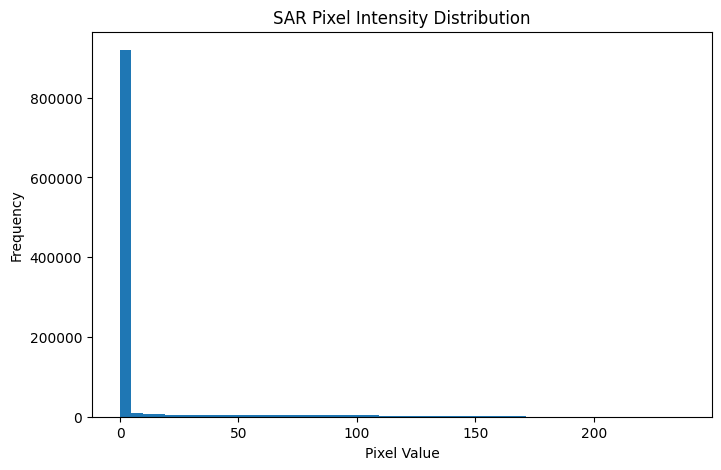

In [20]:
sample_sar = tiff.imread(os.path.join(post_path, post_files[0]))

plt.figure(figsize=(8,5))

plt.hist(sample_sar.flatten(), bins=50)

plt.title("SAR Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.show()